In [1]:
import numpy as np
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.coordinates import Galactocentric

In [2]:
def sample_stat(_sample):
    # 输入：包含所有抽样样本的数组
    # 功能：返回样本的[中位值，16分位数，84分位数，上误差，下误差，平均误差]，原始样本
    _mid = np.nanpercentile(_sample,50)
    _l = np.nanpercentile(_sample,16)
    _h = np.nanpercentile(_sample,84)
    _errup = _h-_mid
    _errdn = _mid-_l
    _errm = 0.5*(_errup+_errdn)
    r = [_mid, _l, _h, _errup, _errdn, _errm]
    return r,_sample

In [3]:
# 可处理单个或列表
# vrf mc
# 视向速度红移为正，蓝移为负
def cal_vrf(coord, vlos):
    # 输入：SkyCoord坐标对象，视向速度(km/s，纯数字)
    # 函数返回银心静止系视向速度vrf (km/s，纯数字)
    l = coord.galactic.l.value
    b = coord.galactic.b.value    
    U = 11.69 # 7.01
    W = 7.67  # 4.95
    V = 252.23 # *8.34kpc,-6.379mas yr-1    
    return vlos + U*np.cos(b/180*np.pi)*np.cos(l/180*np.pi) + V*np.cos(b/180*np.pi)*np.sin(l/180*np.pi)+W*np.sin(b/180*np.pi)
    
# 测试
#coord = SkyCoord(ra=245.086520,dec=37.794456, unit=(u.deg,u.deg), frame='icrs') # HVS2
#cal_vrf(coord, vlos=341.10)

In [4]:
def cal_vrf_mc(RAdeg, DEdeg, vlos, vloserr, n=5000, frame='icrs'):
    # 输入：赤经赤纬(deg，纯数字)，视向速度和误差(km/s，纯数字)，抽样个数
    # 函数进行蒙特卡洛采样，返回vrf的全部统计结果(km/s，纯数字)
    coord = SkyCoord(ra=RAdeg*u.degree, dec=DEdeg*u.degree, frame=frame)

    _err = np.random.normal(loc=0, scale=vloserr, size=n)
    vlos_sample = vlos + _err # 抽样10000个
    
    vrf_sample = np.empty(n)
    for i in range(n):
        _draw = cal_vrf(coord, vlos_sample[i])
        vrf_sample[i] = _draw
    return sample_stat(vrf_sample)

# 测试
#cal_vrf_mc(RAdeg=245.086520, DEdeg=37.794456, vlos=341.10, vloserr=7.79, n=1000) # HVS2 502.33±8.37 km/s

([504.90003574988185,
  497.18627220996336,
  512.9856908163663,
  8.085655066484435,
  7.713763539918489,
  7.899709303201462],
 array([502.86822611, 506.44249902, 495.69205892, 497.56707745,
        516.97786686, 512.75608786, 498.41583075, 503.43522837,
        491.53275659, 493.12200704, 506.91108634, 500.05009832,
        500.49070272, 509.9798072 , 504.17675098, 492.68394774,
        505.18542513, 501.63770591, 522.75602843, 502.87188   ,
        498.89877343, 500.59042954, 506.6931547 , 512.3388714 ,
        504.2552669 , 514.6980842 , 501.80516269, 497.4794418 ,
        486.93305266, 525.99361367, 503.73928669, 516.13147066,
        500.60342027, 509.06731426, 512.54202169, 510.10643068,
        510.92831636, 513.06959967, 499.31441919, 500.76725747,
        512.56820842, 507.98900016, 494.41808174, 519.71781459,
        493.75574937, 504.79397458, 514.53386002, 503.89459545,
        499.57127791, 515.81138557, 519.72244628, 490.88793715,
        517.48379451, 514.0472399 , 508

In [5]:
def cal_LMdist(M,m,ebv3d,R=2.364): 
    # 输入：绝对星等，视星等，ebv(改正到STD)，消光系数RG=2.364
    # 返回光度距离
    A = R*ebv3d
    return 10**(0.2*(m-M+5-A))

def cal_LMdist_mc(M,Merr, m,merr, ebv3d,R=2.364, n=1000): # 蒙特卡洛计算
    # 输入：绝对星等和误差，视星等和误差，ebv(改正到STD)，消光系数RG=2.364
    # 返回光度距离的全部统计结果
    _err = np.random.normal(loc=0, scale=Merr, size=n) 
    M_sample = M + _err 
    _err = np.random.normal(loc=0, scale=merr, size=n) 
    m_sample = m + _err 
    
    d_sample = np.empty(n)
    for i in range(n):
        d_sample[i] = cal_LMdist(M_sample[i],m_sample[i],ebv3d,R)
    return sample_stat(d_sample)

# 测试 
#cal_LMdist_mc(M=-1.7,Merr=0.63,m=15.1,merr=0.03,ebv3d=0.015,R=3.1,n=5000) # HVS2 22.24kpc

([22367.89902539621,
  16926.36032516051,
  29741.069654295155,
  7373.170628898944,
  5441.538700235702,
  6407.354664567323],
 array([19443.52099622, 20620.4347832 , 18975.85669179, ...,
        11335.39311696, 31690.59714739, 20477.19206276]))

In [6]:
# XYZ rR mc
def cal_3dloc(ra,dec,dist,frame='icrs'):
    # 输入：赤经赤纬，距离(需要加astropy.unit)，坐标参考系
    # 返回X,Y,Z(带单位，太阳X=-8.3kpc)
    coord = SkyCoord(ra=ra, dec=dec, distance=dist, frame=frame).transform_to(Galactocentric).cartesian
    return coord.x,coord.y,coord.z

def cal_3dloc_mc(ra,dec,dist,dist_lo,dist_hi,frame='icrs',n=10000):
    # 输入：赤经赤纬，距离(deg,pc,纯数字)，坐标参考系，抽样个数
    # 返回X,Y,Z,银盘面说到银心的距离R，银心距r，全部统计结果
    dist_sample = np.empty(n)
    for i in range(n):
        randi = np.random.rand()
        if randi<0.5: # 抽正样本
            while True:
                eup = np.random.normal(loc=0, scale=(dist_hi-dist))
                if eup>0:
                    dist_sample[i] = dist + eup
                    break
        else: #抽负样本
            while True:
                edn = np.random.normal(loc=0, scale=(dist-dist_lo))
                if edn<0 and (dist+edn)>0: # 防止负距离
                    dist_sample[i] = dist + edn
                    break
    #print(dist_sample)                
    xs,ys,zs,Rs,rs = np.empty(n),np.empty(n),np.empty(n),np.empty(n),np.empty(n)
    for i in range(n):
        x,y,z = cal_3dloc(ra=ra*u.degree,dec=dec*u.degree,dist=dist_sample[i]*u.pc,frame=frame)
        xs[i] = x.to(u.kpc).value
        ys[i] = y.to(u.kpc).value
        zs[i] = z.to(u.kpc).value
        Rs[i] = np.sqrt(xs[i]**2+ys[i]**2)
        rs[i] = np.sqrt(xs[i]**2+ys[i]**2+zs[i]**2) # 银心距kpc
    return sample_stat(xs),sample_stat(ys),sample_stat(zs),sample_stat(Rs),sample_stat(rs)
# 测试
#x,y,z,R,r = cal_3dloc_mc(ra=344.6565,dec=40.00147,dist=27.9*1000,dist_lo=(27.9-1.5)*1000,dist_hi=(27.9+1.5)*1000,n=1000) # X=-8.3kpc
#x,y,z,R,r

(([-13.018878400159956,
   -13.276674256661716,
   -12.752165572413924,
   0.2667128277460318,
   0.25779585650175996,
   0.26225434212389587],
  array([-13.02969103, -13.17759634, -13.26062035, -12.5373795 ,
         -12.63690645, -13.14351679, -12.17633703, -12.80067868,
         -12.89033352, -12.82496761, -12.60119938, -12.99168707,
         -12.47190809, -13.04418653, -12.55742618, -13.05179018,
         -13.3145648 , -13.0017781 , -12.90199202, -12.72000994,
         -13.0567572 , -13.05973497, -13.30724551, -12.99780993,
         -13.41400924, -13.14935205, -13.14983337, -13.52086256,
         -13.01368423, -12.92149604, -12.59626751, -13.76200305,
         -12.79335504, -12.65047606, -13.01379834, -12.65941559,
         -13.11749762, -13.00690974, -13.141337  , -13.22495715,
         -13.09981533, -12.86907667, -12.70971279, -12.84452789,
         -12.3819035 , -13.30198089, -12.73716186, -12.72449122,
         -13.14691395, -12.62272908, -13.23568811, -12.81067487,
         -1

In [41]:
#cal_3dloc_mc(ra=344.6565,dec=40.00147,dist=.1,dist_lo=0.01,dist_hi=0.2,n=100)

(([-8.12198952456421,
   -8.12200267976975,
   -8.121978938855095,
   1.0585709114607766e-05,
   1.3155205540016368e-05,
   1.1870457327312067e-05],
  array([-8.12203993, -8.12200668, -8.12198354, -8.12197821, -8.12198366,
         -8.12201395, -8.12198603, -8.12199211, -8.12198541, -8.12199673,
         -8.12197546, -8.12198306, -8.12198361, -8.12197895, -8.12197529,
         -8.12199429, -8.12199266, -8.12200645, -8.12200318, -8.12199043,
         -8.12199778, -8.12197406, -8.12197951, -8.12198051, -8.12200955,
         -8.1219904 , -8.12199841, -8.12198978, -8.1219913 , -8.12200688,
         -8.12198356, -8.12197762, -8.1219895 , -8.12201006, -8.12197979,
         -8.12200143, -8.12201385, -8.12197578, -8.1220023 , -8.12198368,
         -8.12203367, -8.1219898 , -8.12197692, -8.12198718, -8.12198741,
         -8.12199183, -8.12199066, -8.12200239, -8.12198337, -8.1220007 ,
         -8.1219891 , -8.1220178 , -8.1220008 , -8.12198353, -8.12198517,
         -8.12197706, -8.12198909, -8

In [7]:
from PyAstronomy.pyasl import gal_uvw

def cal_3dvel(ra,dec,pmra,pmdec,dist,vlos):
    # 输入不加单位，deg,mas/yr,pc,km/s
    # 返回U,V,W(LSR) in km/s
    lsr_huang = (11.69, 10.16, 7.67)
    '''
    U: Velocity (km/s) positive toward the Galactic center 
    V: Velocity (km/s) positive in the direction of Galactic rotation 
    W: Velocity (km/s) positive toward the North Galactic Pole
    '''
    return gal_uvw(ra=ra, dec=dec, pmra=pmra, pmdec=pmdec, distance=dist, vrad=vlos, lsr=lsr_huang)

# 测试
#cal_3dvel(ra=262.6717,dec=-23.7501, pmra=-4.363,pmdec=-9.627, dist=4540, vlos=144.9)

(169.28277004719456, -207.8382852619772, -11.873396729745268)

In [8]:
#from matplotlib import pyplot as plt
def cal_3dvel_mc(ra,dec, pmra,pmdec,pmra_err,pmdec_err, dist,dist_lo,dist_hi, vlos,vlos_err,n=10000):
    # 输入：不加单位
    # 返回：U,V,W(LSR),总速度in km/s全部统计结果
    # 抽距离样本
    dist_sample = np.empty(n)
    for i in range(n):
        randi = np.random.rand()
        if randi<0.5: # 抽正样本
            while True:
                eup = np.random.normal(loc=0, scale=(dist_hi-dist))
                if eup>0:
                    dist_sample[i] = dist + eup
                    break
        else: #抽负样本
            while True:
                edn = np.random.normal(loc=0, scale=(dist-dist_lo))
                if edn<0 and (dist+edn)>0: # 防止负距离
                    dist_sample[i] = dist + edn
                    break
    _err = np.random.normal(loc=0, scale=vlos_err, size=n)
    vlos_sample = vlos + _err 
    _err = np.random.normal(loc=0, scale=pmra_err, size=n)
    pmra_sample = pmra + _err 
    _err = np.random.normal(loc=0, scale=pmdec_err, size=n)
    pmdec_sample = pmdec + _err 

    us,vs,ws = np.empty(n),np.empty(n),np.empty(n)
    vtots = np.empty(n)
    for i in range(n):
        u,v,w = cal_3dvel(ra,dec,pmra_sample[i],pmdec_sample[i],dist_sample[i],vlos_sample[i])
        us[i] = u
        vs[i] = v
        ws[i] = w
        vtots[i] = np.sqrt(u**2+(v+230.)**2+w**2)
    #plt.hist(dist_sample,bins=101)
    #print(np.percentile(dist_sample,50),np.percentile(dist_sample,16),np.percentile(dist_sample,84))
    return sample_stat(us),sample_stat(vs),sample_stat(ws),sample_stat(vtots)
    
#cal_3dvel_mc(ra=185.62336,dec=+40.82654,
#            pmra=-12.94,pmdec=17.08,pmra_err=1.35,pmdec_err=1.43,
#            dist=12000,dist_lo=9000,dist_hi=17000,vlos=220,vlos_err=10,n=10000)

(([-1131.3177073347292,
   -1573.9848306429226,
   -846.0435828215536,
   285.2741245131756,
   442.66712330819337,
   363.9706239106845],
  array([ -801.94399421, -1034.02691683, -1012.77840406, ...,
         -1356.85879558,  -954.36182296, -1002.93723422])),
 ([523.7194497480041,
   378.1831623229506,
   725.4143284996582,
   201.69487875165407,
   145.5362874250535,
   173.6155830883538],
  array([328.8479705 , 506.81320069, 603.27855464, ..., 623.54560847,
         425.05667471, 433.43878975])),
 ([-92.80379408431622,
   -217.5968598549368,
   -10.844184379727508,
   81.95960970458871,
   124.79306577062059,
   103.37633773760464],
  array([  18.16788827,  -65.05801567,  -86.31214354, ..., -163.14234574,
          -54.85447231,  -64.35084252])),
 ([1364.1081641449364,
   1055.7338630515394,
   1850.1118949674951,
   486.00373082255874,
   308.374301093397,
   397.18901595797786],
  array([ 977.62738104, 1271.35278457, 1314.35270436, ..., 1611.27940528,
         1158.84198635, 1204.

In [2]:
import numpy as np
from galpy.potential import MWPotential2014
from galpy.orbit import Orbit
import astropy.units as u
from matplotlib import pyplot as plt

init parameters (galectocentric; x-anti_GC/y-rotation/z-north):
xyz_t0: 3.825 0.206 0.452 kpc  vxyz_t0: -169.233 22.162 -12.266 km/s  vtot_t0: 171.119 km/s  R_t0: 3.8  r_t0: 3.9 kpc
xyz_t0: 28.641 17.104 -26.154 kpc  vxyz_t0: 300.839 80.412 -401.662 km/s  vtot_t0: 508.235 km/s  R_t0: 33.4  r_t0: 42.4 kpc
xyz_t0: 10.249 14.867 -25.966 kpc  vxyz_t0: 86.990 172.073 -467.677 km/s  vtot_t0: 505.864 km/s  R_t0: 18.1  r_t0: 31.6 kpc


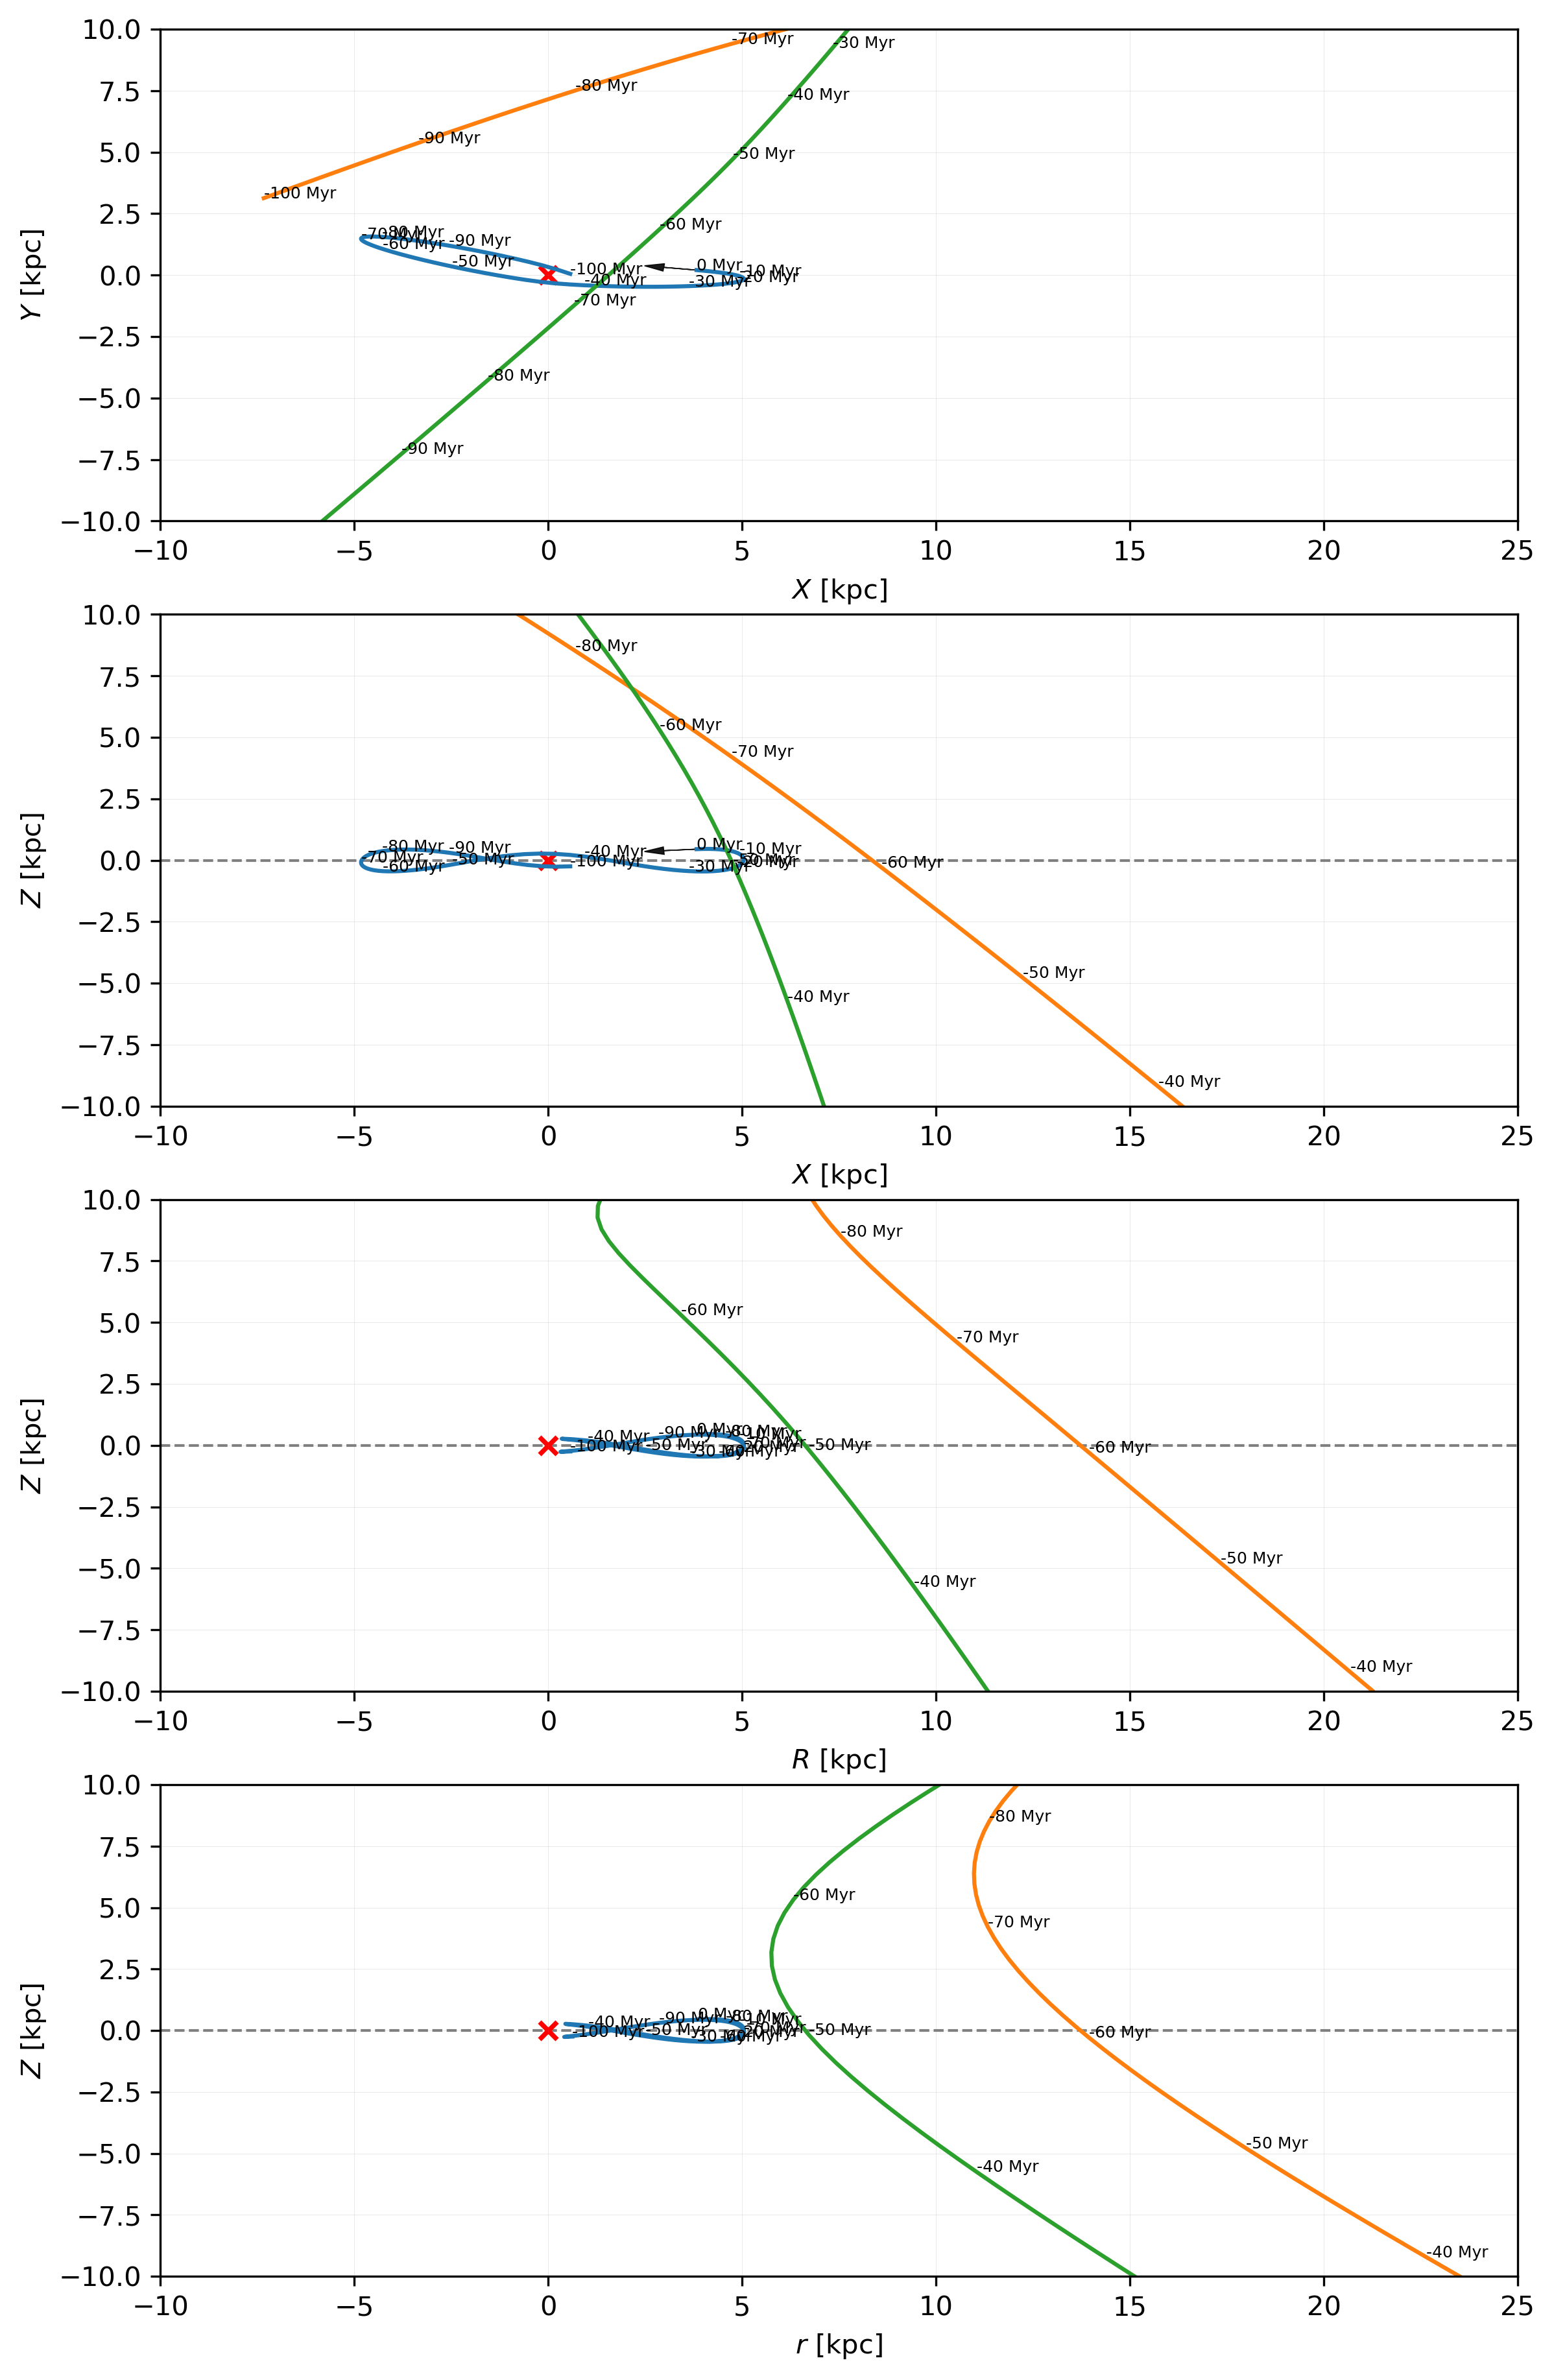

[<Table length=101>
 Time(Myr)        X(kpc)               Y(kpc)               Z(kpc)        ...       Vx(km/s)            Vy(km/s)           Vz(km/s)          Vtot(km/s)    
  float32        float64              float64              float64        ...       float64             float64            float64            float64      
 --------- -------------------- -------------------- -------------------- ... ------------------- ------------------- ------------------ ------------------
       0.0   3.8252130571403957  0.20564591095434392   0.4520871663893643 ... -12.266481155837205  3.8307368968919824  3.857321347674261  171.1185034928102
      -1.0   3.9916017317657375  0.18263954930735268  0.46083228829851947 ...  -4.911551904571581  3.9957779705592285  4.022264037571984 157.95035632015137
      -2.0    4.144865565414633    0.159031508981811   0.4622833457279599 ...  2.0034023486619295  4.1479153289585105  4.173596466831267 145.45636560861885
      -3.0    4.285341050995171   0.13493189

In [17]:
from astropy.table import Table

def cal_orb(ras,decs,dists,pmras,pmdecs,rvs, time_Myr=100,t_num=51,t_step_Myr=10, ifplot=True, ifshow=False, save_path=None):
    # 输入：可以是列表数组或单个数，不加单位，t_num是分成多少个时间点计算结果，t_step_Myr是绘图时显示时间的间隔
    # 对每一个星返回轨道参数表格
    solarmotion = [-11.69,10.16,7.67]*u.km/u.s # (-U,V,W)
    Ro = 8.34 *u.kpc
    Vo = 230 *u.km/u.s
    vxvv = [ras*u.deg, decs*u.deg, dists*u.kpc, pmras*u.mas/u.yr, pmdecs*u.mas/u.yr, rvs*u.km/u.s]
    o = Orbit(vxvv=vxvv, ro=Ro, vo=Vo, solarmotion=solarmotion, radec=True)
    # 回溯轨道
    ts = np.linspace(0,time_Myr,t_num)*u.Myr
    o.integrate(ts, MWPotential2014)
    
    if ifplot:
        # 绘制轨道并添加时间标注
        fig, ax = plt.subplots(4, 1, figsize=(9,15), dpi=300) # (10,15)
        plt.subplots_adjust(hspace=0.19)
        print('init parameters (galectocentric; x-anti_GC/y-rotation/z-north):')
        stp = int(len(ts)//t_step_Myr)
        # x-y 轨迹
        
        for k in range(len(o.x(ts[0]))):
            ax[0].plot(o.x(ts)[k], o.y(ts)[k], label='orbit')
            for i in range(len(ts)):
                if i%stp == 0:
                    ax[0].annotate(f'{ts[i].value:.0f} Myr', (o.x(ts[i])[k], o.y(ts[i])[k]), fontsize=6.)
            ax[0].arrow(o.x(ts[0])[k], o.y(ts[0])[k],o.vx(ts[0])[k]/200,o.vy(ts[0])[k]/200,
                        head_width=0.3, head_length=0.5, linewidth=0.4, fc='k', ec='k',alpha=0.9,zorder=1)
            print(f'xyz_t0: {o.x(ts[0])[k]:.3f} {o.y(ts[0])[k]:.3f} {o.z(ts[0])[k]:.3f} kpc'+'  '+\
                        f'vxyz_t0: {o.vx(ts[0])[k]:.3f} {o.vy(ts[0])[k]:.3f} {o.vz(ts[0])[k]:.3f} km/s'+'  '+\
                        f'vtot_t0: {np.sqrt(o.vx(ts[0])[k]**2+o.vy(ts[0])[k]**2+o.vz(ts[0])[k]**2):.3f} km/s'+'  '\
                        f'R_t0: {np.sqrt(o.x(ts[0])[k]**2+o.y(ts[0])[k]**2):.1f}'+'  '+\
                        f'r_t0: {np.sqrt(o.x(ts[0])[k]**2+o.y(ts[0])[k]**2+o.z(ts[0])[k]**2):.1f} kpc')
        ax[0].scatter(0, 0, facecolor='r', marker='x', linewidths=1.75, s=42, zorder=1)
        ax[0].set_xlabel(r'$X$ [kpc]',fontsize=10)
        ax[0].set_ylabel(r'$Y$ [kpc]',fontsize=10)
        ax[0].set_xlim(-10,25)
        ax[0].set_ylim(-10,10) 
        ax[0].grid(True,zorder=0,linewidth=0.2,alpha=0.2,c='grey')
        # x-z 轨迹
        
        for k in range(len(o.x(ts[0]))):
            ax[1].plot(o.x(ts)[k], o.z(ts)[k], label='orbit')
            for i in range(len(ts)):
                if i%stp == 0:
                    ax[1].annotate(f'{ts[i].value:.0f} Myr', (o.x(ts[i])[k], o.z(ts[i])[k]), fontsize=6.)
            ax[1].arrow(o.x(ts[0])[k], o.z(ts[0])[k],o.vx(ts[0])[k]/200,o.vz(ts[0])[k]/200,
                        head_width=0.3, head_length=0.5, linewidth=0.4, fc='k', ec='k',alpha=0.9,zorder=1)
        ax[1].axhline(y=0,c='gray',linewidth=1.,linestyle='dashed',alpha=1,zorder=0)
        ax[1].scatter(0, 0, facecolor='r', marker='x', linewidths=1.75, s=42, zorder=1)
        ax[1].set_xlabel(r'$X$ [kpc]',fontsize=10)
        ax[1].set_ylabel(r'$Z$ [kpc]',fontsize=10)
        ax[1].set_xlim(-10,25)
        ax[1].set_ylim(-10,10) 
        ax[1].grid(True,zorder=0,linewidth=0.2,alpha=0.2,c='grey')
        # R-z 轨迹
        for k in range(len(o.x(ts[0]))):
            ax[2].plot(o.R(ts)[k], o.z(ts)[k], label='R-z')
            for i in range(len(ts)):
                if i%stp == 0:
                    ax[2].annotate(f'{ts[i].value:.0f} Myr', (o.R(ts[i])[k], o.z(ts[i])[k]), fontsize=6.)
        ax[2].axhline(y=0,c='gray',linewidth=1.,linestyle='dashed',alpha=1,zorder=0)
        ax[2].scatter(0, 0, facecolor='r', marker='x', linewidths=1.75, s=42, zorder=1)
        ax[2].set_xlabel(r'$R$ [kpc]',fontsize=10)
        ax[2].set_ylabel(r'$Z$ [kpc]',fontsize=10)
        ax[2].set_xlim(-10,25)
        ax[2].set_ylim(-10,10)   
        ax[2].grid(True,zorder=0,linewidth=0.2,alpha=0.2,c='grey')
        # r-z 轨迹
        
        for k in range(len(o.x(ts[0]))):
            ax[3].plot(o.r(ts)[k], o.z(ts)[k], label='r-z')
            for i in range(len(ts)):
                if i%stp == 0:
                    ax[3].annotate(f'{ts[i].value:.0f} Myr', (o.r(ts[i])[k], o.z(ts[i])[k]), fontsize=6.)
        ax[3].axhline(y=0,c='gray',linewidth=1.,linestyle='dashed',alpha=1,zorder=0)
        ax[3].scatter(0, 0, facecolor='r', marker='x', linewidths=1.75, s=42, zorder=1)
        ax[3].set_xlabel(r'$r$ [kpc]',fontsize=10)
        ax[3].set_ylabel(r'$Z$ [kpc]',fontsize=10)
        ax[3].set_xlim(-10,25)
        ax[3].set_ylim(-10,10)   
        ax[3].grid(True,zorder=0,linewidth=0.2,alpha=0.2,c='grey')
        if save_path is not None:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        if ifshow:
            plt.show()
        plt.close()
        plt.close('all')
    tbls = []
    for k in range(len(o.x(ts[0]))):
        tbl = Table(names=['Time(Myr)','X(kpc)','Y(kpc)','Z(kpc)','r(kpc)','R(kpc)','Vx(km/s)','Vy(km/s)','Vz(km/s)','Vtot(km/s)'],
                    dtype=['f4','f8','f8','f8','f8','f8','f8','f8','f8','f8'])
        for i in range(len(ts)):
            tbl.add_row([ts[i],o.x(ts[i])[k],o.y(ts[i])[k],o.z(ts[i])[k],\
                         o.vx(ts[i])[k],o.vy(ts[i])[k],o.vz(ts[i])[k],o.R(ts[i])[k],o.r(ts[i])[k],\
                        np.sqrt(o.vx(ts[i])[k]**2+o.vy(ts[i])[k]**2+o.vz(ts[i])[k]**2)])
        tbls.append(tbl)
    return tbls # x从银心指向太阳

def cal_orb_mc():
    pass
# 测试    
# 设置初始参数
# ras = [262.6717,25.278694,0.278694]
# decs = [-23.7501,16.532547,0.278694]
# dists = [4.54,37.28,30] # kpc
# pmras = [-4.363,1.461,1.461]
# pmdecs = [-9.627,-1.564,-1.564]
# rvs = [144.9,384.3,384.3]
# #(ra=262.6717,dec=-23.7501, pmra=-4.363,pmdec=-9.627, dist=4540, vlos=144.9) 169,-207,-11.8 galuvw x指向银心 这是相对LSR U=0207+230=23
# cal_orb(ras,decs,dists,pmras,pmdecs,rvs, time_Myr=-100,t_num=101, ifshow=True,save_path='./Temp/orbit_test5.png') # 计算的是相对银心 x指向太阳(反银心)

In [6]:
def pre_input(x):
    # 处理输入数据使得单个数字，列表和数组通用
    if isinstance(x, (int, float)):
        return np.array([x])
    else:
        return np.array(x)

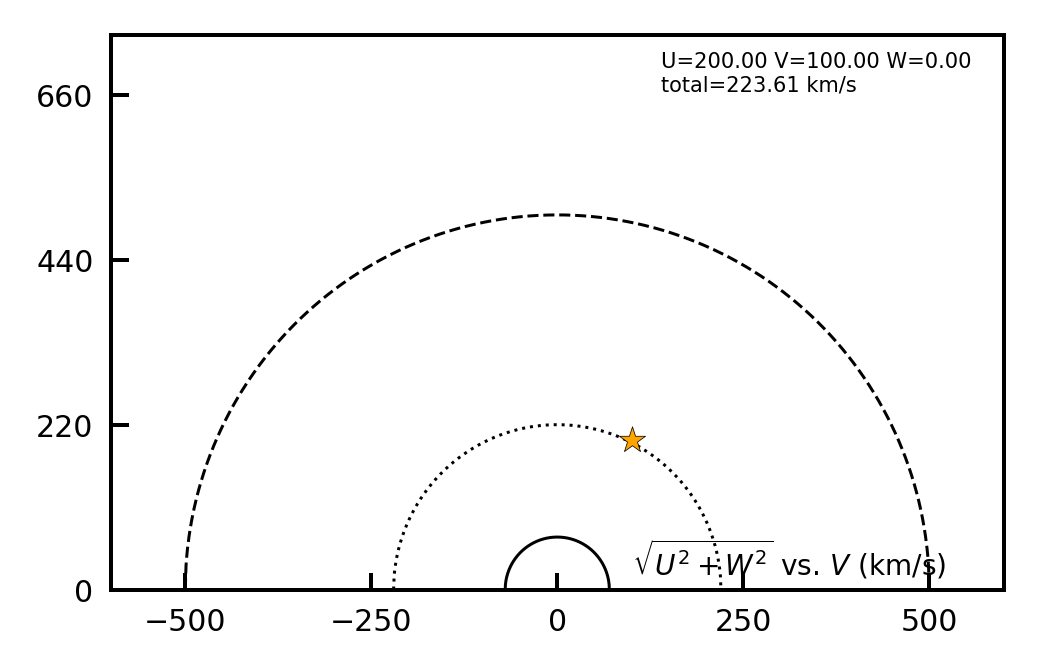

In [283]:
def plot_toomre(U,V,W,save_path=None):
    # 输入U,V,W in km/s
    # 在Toomre图上显示U,V,W
    U,V,W = pre_input(U),pre_input(V),pre_input(W)
    
    plt.figure(figsize=(3.2,2),dpi=360)
    s1=70 # 薄盘
    x1=np.arange(-s1,s1+s1/210,s1/210)
    y1=[np.sqrt(s1*s1-i*i) for i in x1]
    s2=500  # 晕
    x2=np.arange(-s2,s2+s2/500,s2/500)
    y2=[np.sqrt(s2*s2-i*i) for i in x2]
    s3=220  # 厚盘
    x3=np.arange(-s3,s3+s3/600,s3/300)
    y3=[np.sqrt(s3*s3-i*i) for i in x3]
    
    UW = np.sqrt(U*U+W*W)
    vtot = np.sqrt(U*U+V*V+W*W) 

    plt.scatter(V,UW,marker='*',s=30,edgecolors='k',facecolor='orange',linewidths=0.15, zorder=3)
    plt.plot(x1,y1,color='black',linewidth=0.6,linestyle='solid', zorder=2) # 薄盘70
    plt.plot(x2,y2,color='black',linewidth=0.6,linestyle='dashed', zorder=2) # 晕500
    plt.plot(x3,y3,color='black',linewidth=0.6,linestyle='dotted', zorder=2) # 厚盘220
    plt.xticks(np.arange(-1500,1500,250),fontsize=6)
    plt.yticks(np.arange(0,1400,220),fontsize=6)
    plt.ylim((0,740))
    plt.xlim((-600,600))
    if len(U)==1:
        plt.text(140,666,f'U={U[0]:.2f} V={V[0]:.2f} W={W[0]:.2f}\ntotal={vtot[0]:.2f} km/s',
             fontsize=4.2)
    #plt.text(100,20,r'$\sqrt{{U_{\rm LSR}}^2+{W_{\rm LSR}}^2}$ vs. $V_{\rm LSR}\ {\rm (km/s)}$',fontsize=4.5)
    plt.text(100,20,r'$\sqrt{U^2+W^2}$ vs. $V\ {\rm (km/s)}$',fontsize=5.6)
    if save_path is not None:
        plt.savefig(save_path, dpi=360, bbox_inches='tight')

## UVW vtot mc
## plot XYZ-UVW mchist
## plot Toomre mchist
## Orbit Integration mchist
#U=[155.8]
#V=[-20.4]
#W=[283.5]
#plot_toomre(U=200,V=100,W=0,save_path='./Temp/toomre_test2.png')

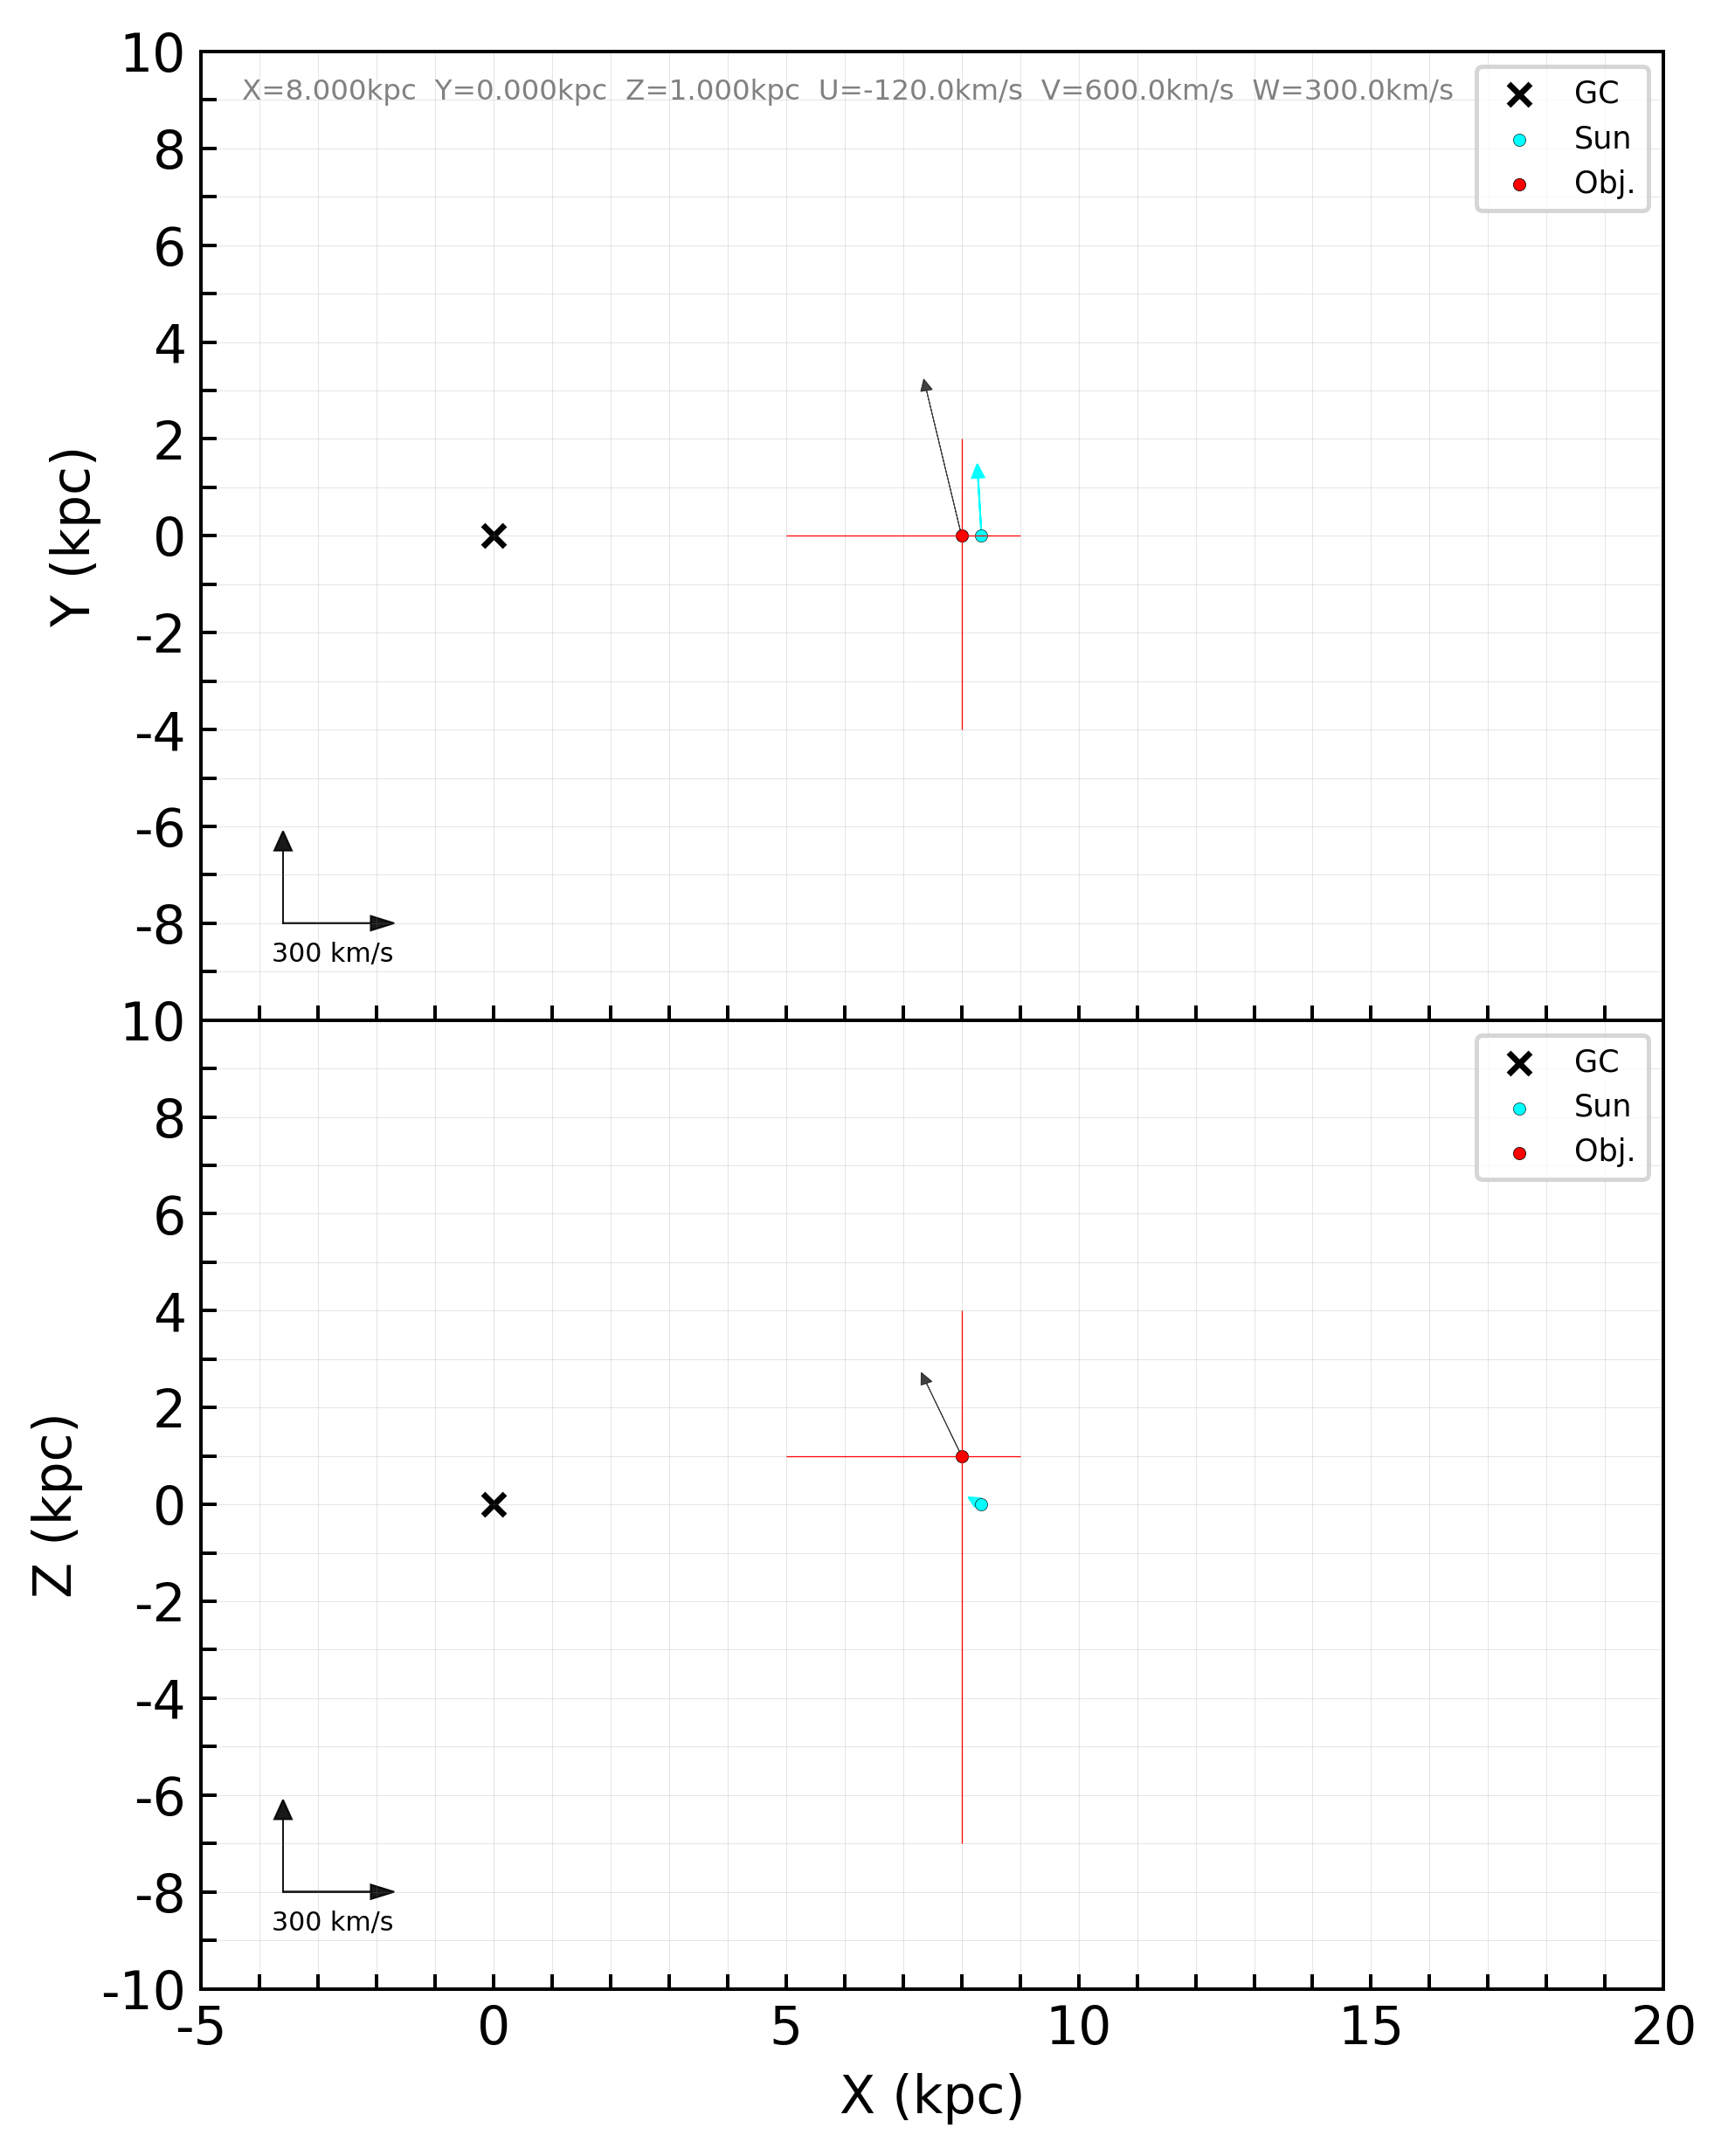

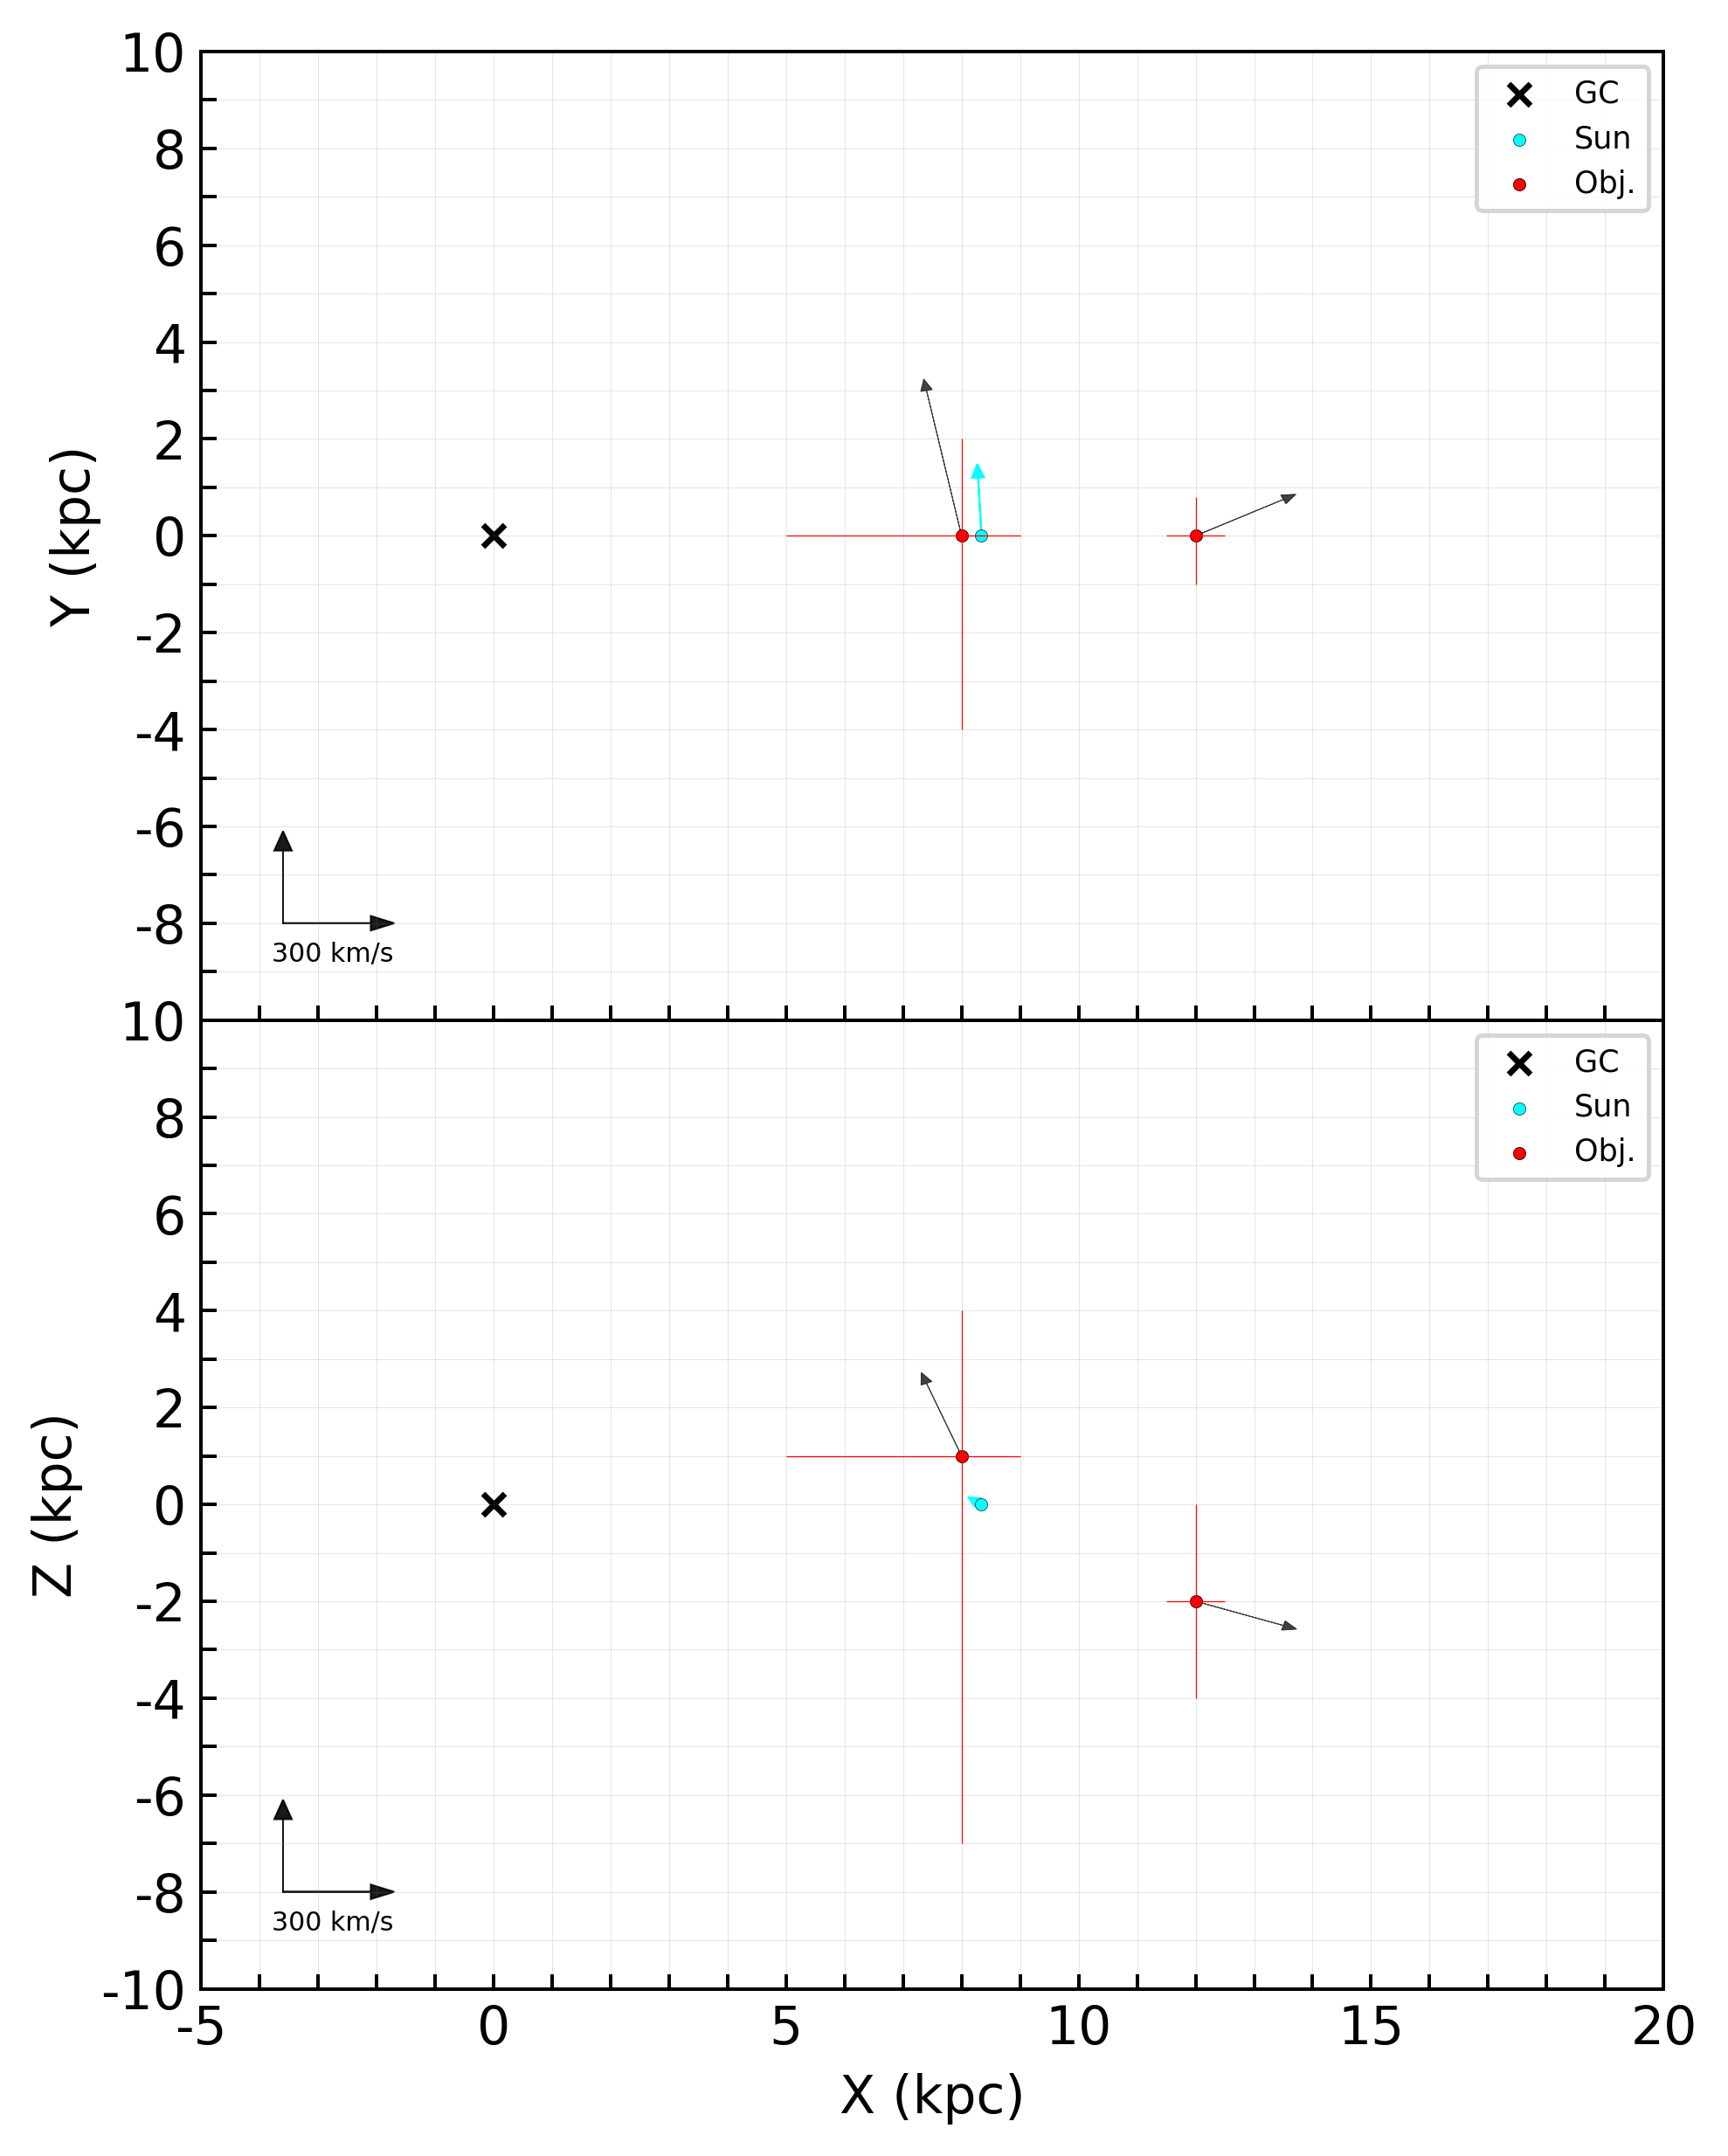

In [17]:
def plot_6d(X,Y,Z,Xerrup=None,Xerrdn=None,Yerrup=None,Yerrdn=None,Zerrup=None,Zerrdn=None,U=None,V=None,W=None,save_path=None,text=True):
    # X,Y,Z in kpc, 这里太阳位于X=8.34kpc，U与X同向
    X,Y,Z = pre_input(X),pre_input(Y),pre_input(Z)
    iferr, ifvel = False, False
    if Xerrup is not None and Xerrdn is not None and Yerrup is not None and Yerrdn is not None and Zerrup is not None and Zerrdn is not None:
        iferr = True
        Xerrup,Yerrup,Zerrup = pre_input(Xerrup),pre_input(Yerrup),pre_input(Zerrup)
        Xerrdn,Yerrdn,Zerrdn = pre_input(Xerrdn),pre_input(Yerrdn),pre_input(Zerrdn)
    if U is not None and V is not None and W is not None:
        ifvel = True
        U,V,W = pre_input(U),pre_input(V),pre_input(W)
    
    plt.figure(figsize=(6,8),dpi=360)
    plt.subplots_adjust(wspace=0, hspace=0.00)#调整子图间距

    plt.subplot(2,1,1)
    plt.grid(True,zorder=0,linewidth=0.2,alpha=0.2,c='grey')
    st = plt.scatter(X,Y, edgecolors='k',facecolor='r', marker='o',linewidths=0.15, s=8, zorder=4)
    if iferr:
        plt.errorbar(X,Y,xerr=[Xerrdn,Xerrup],yerr=[Yerrdn,Yerrup],
                     linewidth=0.,elinewidth=0.25, capsize=0, color='r',label='',zorder=4)
    if ifvel:
        for i in range(len(X)):
            plt.arrow(X[i],Y[i],   
                      U[i]/200, 
                      V[i]/200,
                      head_width=0.2, head_length=0.24, linewidth=0.2, fc='#111111', ec='#111111',alpha=0.8, zorder=3)        
    sun = plt.scatter(8.34,0, edgecolors='k',facecolor='cyan', marker='o',linewidths=0.12, s=8, zorder=3)
    plt.arrow(8.34, 0,   
              -11.69/200, 
              (230+10.16)/200,
              head_width=0.21, head_length=0.28, linewidth=0.4, fc='cyan', ec='cyan',alpha=0.99,zorder=2)
    gc = plt.scatter(0,0, facecolor='k', marker='x',linewidths=1.35, s=25, zorder=1)
    
    plt.arrow(-3.6, -8.,   300/200, 0/200,
              head_width=0.3, head_length=0.4, linewidth=0.4, fc='k', ec='k',alpha=0.9,zorder=1)
    plt.arrow(-3.6, -8.,   0/200, 300/200,
              head_width=0.3, head_length=0.4, linewidth=0.4, fc='k', ec='k',alpha=0.9,zorder=1)
    plt.text(-3.8,-8.8,'300 km/s',fontsize=6,zorder=1)
    if text and len(X)==1:
        if not ifvel:
            plt.text(-4.3,9,f'X={X[0]:.3f}kpc  Y={Y[0]:.3f}kpc  Z={Z[0]:.3f}kpc', color='grey', fontsize=6.5, zorder=2, alpha=0.99)
        else:
            plt.text(-4.3,9,f'X={X[0]:.3f}kpc  Y={Y[0]:.3f}kpc  Z={Z[0]:.3f}kpc  U={U[0]:.1f}km/s  V={V[0]:.1f}km/s  W={W[0]:.1f}km/s',\
                 color='grey', fontsize=6.5, zorder=2, alpha=0.99)
    plt.xlim(-5,20)
    plt.ylim(-10,10)
    plt.ylabel('Y (kpc)',fontsize=12)
    plt.xticks(np.arange(-5,21,1),['']*len(np.arange(-5,21,1)))
    plt.yticks(np.arange(-9,11,1),[str(int(jj-9)) if jj%2==1 else '' for jj in range(len(np.arange(-9,11,1)))], fontsize=12)
    plt.rcParams['xtick.direction'] = 'in'# 将x周的刻度线方向设置向内
    plt.rcParams['ytick.direction'] = 'in'# 将y轴的刻度方向设置向内
    plt.legend([gc,sun,st],['GC','Sun','Obj.'],loc='upper right',fontsize=7)

    
    plt.subplot(2,1,2)
    plt.grid(True,zorder=0,linewidth=0.2,alpha=0.2,c='grey')
    st = plt.scatter(X,Z, edgecolors='k',facecolor='r', marker='o',linewidths=0.15, s=8, zorder=4)
    if iferr:
        plt.errorbar(X,Z,xerr=[Xerrdn,Xerrup],yerr=[Zerrdn,Zerrup],
                     linewidth=0.,elinewidth=0.25, capsize=0, color='r',label='',zorder=4)
    if ifvel:
        for i in range(len(X)):
            plt.arrow(X[i],Z[i],   
                      U[i]/200, 
                      W[i]/200,
                      head_width=0.2, head_length=0.24, linewidth=0.2, fc='#111111', ec='#111111',alpha=0.8, zorder=3)        
    sun = plt.scatter(8.34,0, edgecolors='k',facecolor='cyan', marker='o',linewidths=0.12, s=8, zorder=3)
    plt.arrow(8.34, 0, -11.69/200, (0+7.67)/200,
              head_width=0.21, head_length=0.2, linewidth=0.4, fc='cyan', ec='cyan',alpha=0.9,zorder=2)
    gc = plt.scatter(0,0, facecolor='k', marker='x',linewidths=1.35, s=25, zorder=1)
    
    plt.arrow(-3.6, -8,   300/200, 0/200,
              head_width=0.3, head_length=0.4, linewidth=0.4, fc='k', ec='k',alpha=0.9,zorder=1)
    plt.arrow(-3.6, -8,   0/200, 300/200,
              head_width=0.3, head_length=0.4, linewidth=0.4, fc='k', ec='k',alpha=0.9,zorder=1)
    plt.text(-3.8,-8.8,'300 km/s',fontsize=6,zorder=1)
    plt.legend([gc,sun,st],['GC','Sun','Obj.'],loc='upper right',fontsize=7)

    plt.xlim(-5,20)
    plt.ylim(-10,10)
    plt.xlabel('X (kpc)',fontsize=12)
    plt.ylabel('Z (kpc)',fontsize=12)
    plt.xticks(np.arange(-5,21,1),[str(int(jj)) if jj%5==0 else '' for jj in np.arange(-5,21,1)], fontsize=12)
    plt.yticks(np.arange(-10,11,1),[str(int(jj)) if jj%2==0 else '' for jj in np.arange(-10,11,1)], fontsize=12) 
    plt.rcParams['xtick.direction'] = 'in'# 将x周的刻度线方向设置向内
    plt.rcParams['ytick.direction'] = 'in'# 将y轴的刻度方向设置向内
    if save_path is not None:
        plt.savefig(save_path,dpi=360,bbox_inches='tight')

# 测试
#plot_6d(X=8.34,Y=0,Z=1,Xerrup=None,Xerrdn=None,Yerrup=None,Yerrdn=None,Zerrup=None,Zerrdn=None,U=100,V=0,W=0,save_path=None)
#plot_6d(X=[8.],Y=[0],Z=[1],Xerrup=[1],Xerrdn=[3],Yerrup=[2],Yerrdn=[4],Zerrup=[3],Zerrdn=[8],\
#        U=[-120],V=[600],W=[300],\
#        save_path='./Temp/6d_test2.png')
#plot_6d(X=[8.,12],Y=[0]*2,Z=[1,-2],Xerrup=[1,0.5],Xerrdn=[3,0.5],Yerrup=[2,0.8],Yerrdn=[4,1.],Zerrup=[3,2],Zerrdn=[8,2],\
#        U=[-120,300],V=[600,150],W=[300,-100],\
#        save_path='./Temp/6d_test3.png')